##  Reading Training Data
 

In [1]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path.cwd()
ARTIFACTS = PROJECT_DIR / "artifacts"
FIGURES = PROJECT_DIR / "figures"
REPORTS = PROJECT_DIR / "reports"
FIGURES.mkdir(exist_ok=True)
REPORTS.mkdir(exist_ok=True)

train = pd.read_csv(ARTIFACTS / "03_train.csv")

for col in [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]:
    if col in train.columns:
        train[col] = pd.to_datetime(train[col], errors="coerce")

print(train.shape)
train.info()

(57885, 22)
<class 'pandas.DataFrame'>
RangeIndex: 57885 entries, 0 to 57884
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       57885 non-null  str           
 1   customer_id                    57885 non-null  str           
 2   order_status                   57885 non-null  str           
 3   order_purchase_timestamp       57885 non-null  datetime64[us]
 4   order_approved_at              57875 non-null  str           
 5   order_delivered_carrier_date   57884 non-null  str           
 6   order_delivered_customer_date  57885 non-null  datetime64[us]
 7   order_estimated_delivery_date  57885 non-null  datetime64[us]
 8   customer_unique_id             57885 non-null  str           
 9   customer_zip_code_prefix       57885 non-null  int64         
 10  customer_city                  57885 non-null  str           
 11  customer_state

##  Missing Values and Statistics


In [2]:
missing = (
    train.isna().sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: x["missing_count"] / len(train) * 100)
    .sort_values("missing_percent", ascending=False)
)

display(missing)
display(train.describe(include="all").T)

,missing_count,missing_percent
order_approved_at,10,0.017276
max_installments,1,0.001728
order_delivered_carrier_date,1,0.001728
payment_count,1,0.001728
total_payment,1,0.001728
order_id,0,0.000000
item_count,0,0.000000
is_late,0,0.000000
unique_sellers,0,0.000000
unique_products,0,0.000000


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,57885,57885,ab9e742195daf35a5169f1439b2706b4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,57885,57885,b477f334a9885afca3b612c03e0d047d,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,57885,2,delivered,57879,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,57885,NaN,NaN,NaN,2018-01-02 10:19:40.846938,2016-09-15 12:16:38,2017-09-14 15:10:48,2018-01-21 14:07:04,2018-05-06 21:45:16,2018-08-29 14:52:00,NaN
order_approved_at,57875,54675,2018-02-27 04:31:10,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_carrier_date,57884,50787,2018-05-09 15:48:00,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_customer_date,57885,NaN,NaN,NaN,2018-01-14 23:13:19.295689,2016-10-13 03:10:34,2017-09-26 18:33:46,2018-02-02 22:33:21,2018-05-16 20:27:02,2018-10-11 16:41:14,NaN
order_estimated_delivery_date,57885,NaN,NaN,NaN,2018-01-26 04:30:47.110650,2016-10-04 00:00:00,2017-10-05 00:00:00,2018-02-16 00:00:00,2018-05-28 00:00:00,2018-10-23 00:00:00,NaN
customer_unique_id,57885,56707,8d50f5eadf50201ccdcedfb9e2ac8455,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,57885.0,NaN,NaN,NaN,35123.612335,1003.0,11325.0,24360.0,58900.0,99980.0,29787.123513


##  Relationship Between Features and Label


In [3]:
if "total_payment" in train.columns:
    display(train.groupby("is_late")["total_payment"].agg([
        "count", "mean", "median"
    ]))

if "customer_state" in train.columns:
    state_late = (
        train.groupby("customer_state")["is_late"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )
    display(state_late.head(15))

,count,mean,median
is_late,,,
0,53188,159.192340,104.755
1,4696,171.975388,112.335


,count,mean
customer_state,,
AL,241,0.253112
SE,205,0.165854
CE,786,0.164122
MA,436,0.162844
PI,275,0.149091
BA,1979,0.142496
RJ,7448,0.135741
RR,23,0.130435
MS,402,0.121891


## Date Analysis


In [4]:
train["purchase_month"] = train["order_purchase_timestamp"].dt.month
train["purchase_weekday"] = train["order_purchase_timestamp"].dt.dayofweek

print("Late ratio by month:")
display(train.groupby("purchase_month")["is_late"].mean())

print("Late ratio by weekday:")
display(train.groupby("purchase_weekday")["is_late"].mean())

Late ratio by month:


purchase_month
1     0.062073
2     0.133860
3     0.169821
4     0.062848
5     0.069280
6     0.020105
7     0.040951
8     0.075822
9     0.057669
10    0.053684
11    0.139720
12    0.081447
Name: is_late, dtype: float64

Late ratio by weekday:


purchase_weekday
0    0.088965
1    0.084554
2    0.076787
3    0.079917
4    0.084194
5    0.075830
6    0.074441
Name: is_late, dtype: float64

## Charts/Plots

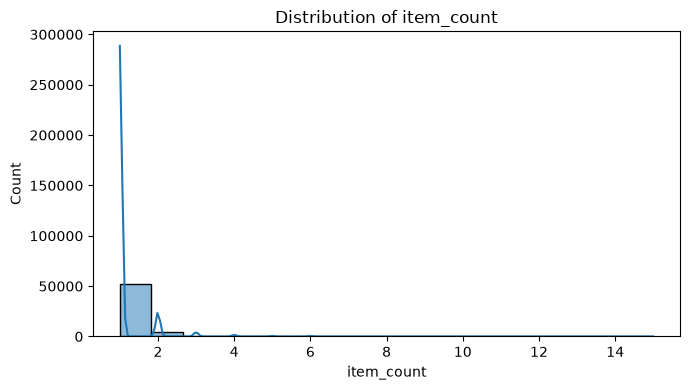

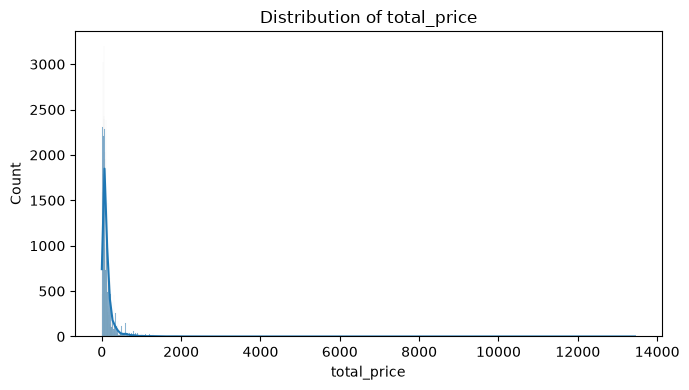

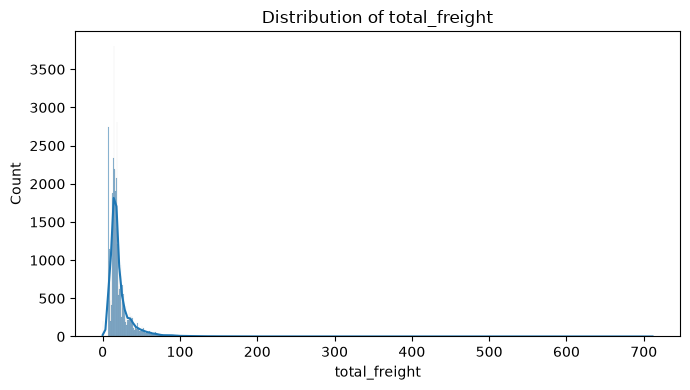

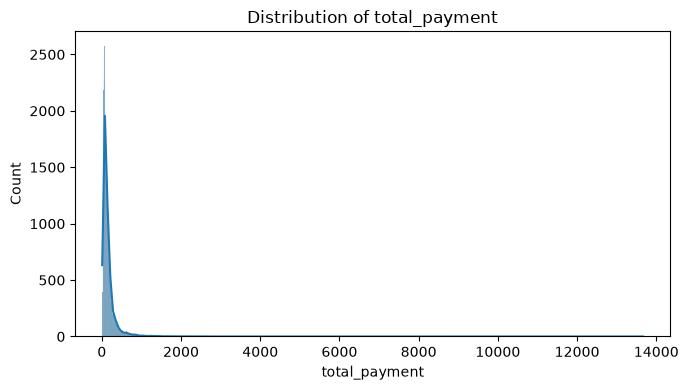

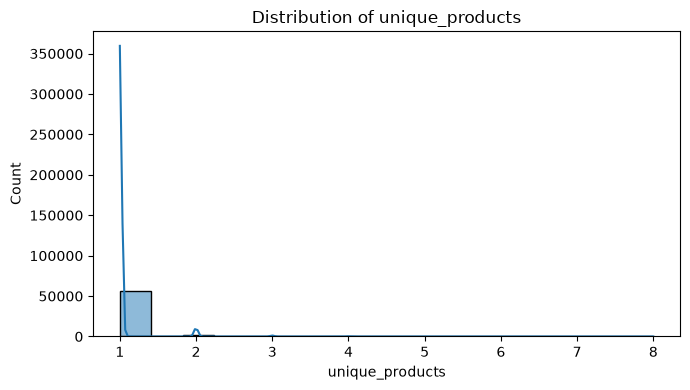

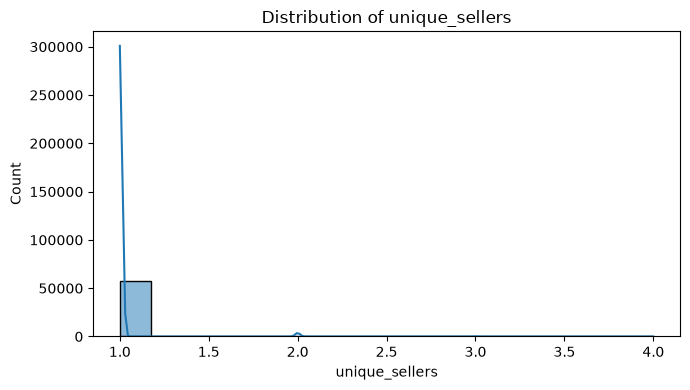

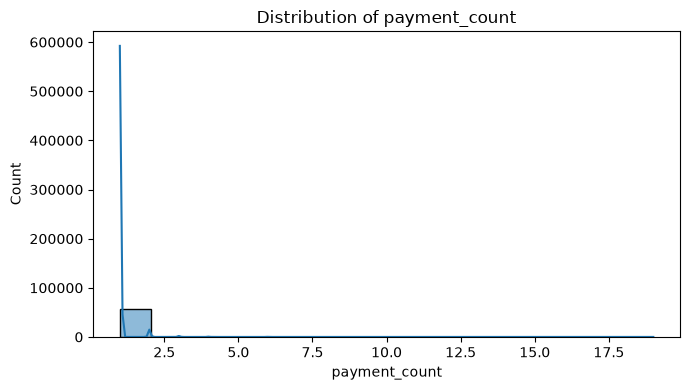

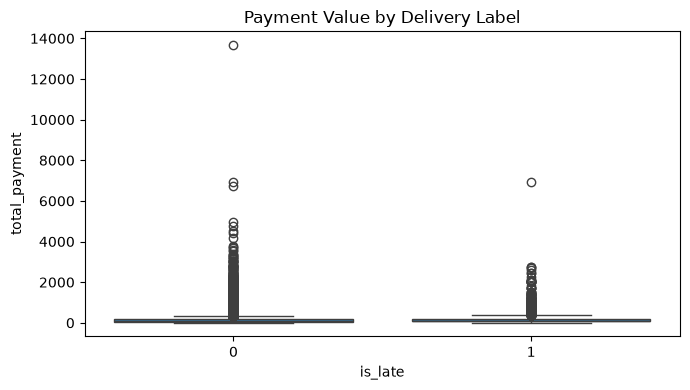

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    col for col in [
        "item_count", "total_price", "total_freight", "total_payment",
        "unique_products", "unique_sellers", "payment_count"
    ] if col in train.columns
]

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(train[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.savefig(FIGURES / f"{col}_distribution.png", dpi=150)
    plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(data=train, x="is_late", y="total_payment")
plt.title("Payment Value by Delivery Label")
plt.tight_layout()
plt.savefig(FIGURES / "payment_by_label.png", dpi=150)
plt.show()

##  Saving EDA Summary

In [6]:
findings = """# EDA Findings

تم تنفيذ التحليل على training split فقط.
تم فحص أبعاد البيانات وأنواعها والقيم المفقودة والإحصاءات الوصفية.
تم فحص توزيع is_late وتحديد نسبة الفئة المتأخرة.
تمت مقارنة الخصائص العددية والولايات مع label.
تم تحليل الشهر ويوم الأسبوع لوقت شراء الطلب.
سيتم استخدام الخصائص المتاحة وقت شراء الطلب فقط في النموذج.
"""

with open(REPORTS / "eda_findings.md", "w", encoding="utf-8") as f:
    f.write(findings)